In [21]:
import numpy as np
from joblib import Parallel, delayed
from Tracer import Trajectory, WindField, PGA
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
import joblib
import pandas as pd

In [11]:
def get_rotated_geometry(direction, r=150):

    theta = np.deg2rad(direction)

    x = -np.cos(theta) * r
    y = -np.sin(theta) * r

    P0_new = np.array([x, y, 0])

    return P0_new

In [30]:
import os
os.chdir("/work3/s234229")
filenames = {file[9:-16]: file for file in os.listdir("nc files") if file.endswith(".nc")}
display(filenames)

{'z0025m_1m': 'flowdata_z0025m_1m_mb_cartesian.nc',
 'xy8m': 'flowdata_xy8m_mb_cartesian.nc',
 'xy16m': 'flowdata_xy16m_mb_cartesian.nc',
 'z04m_16m': 'flowdata_z04m_16m_mb_cartesian.nc',
 'xy1m': 'flowdata_xy1m_mb_cartesian.nc',
 'z01m_4m': 'flowdata_z01m_4m_mb_cartesian.nc',
 'xy2m': 'flowdata_xy2m_mb_cartesian.nc',
 'z02m_8m': 'flowdata_z02m_8m_mb_cartesian.nc',
 'xy4m': 'flowdata_xy4m_mb_cartesian.nc',
 'z005m_2m': 'flowdata_z005m_2m_mb_cartesian.nc'}

In [13]:
wind = {name: WindField(profile='rans', ds=f"nc files/{file}", U_ref=6) for name,file in filenames.items()}
sorted_keys = ['xy1m', 'xy2m', 'xy4m', 'xy8m', 'xy16m', 'z0025m_1m', 'z005m_2m', 'z01m_4m', 'z02m_8m', 'z04m_16m']
plot_keys = ['xy2m', 'xy4m', 'xy8m', 'xy16m', 'z005m_2m', 'z01m_4m', 'z02m_8m', 'z04m_16m']

In [ ]:
def remove_artifacts(wind, key):
    ds = wind[key].ds
    # Apply a rolling window along the x-axis (e.g., 3 or 5 points wide)
    # center=True ensures the window is centered on the pixel being corrected
    u_smoothed = ds.U.rolling(x=3, center=True).median()
    u_smoothed = u_smoothed.rolling(y=3, center=True).median()

    # Fill the edges (which become NaN due to the rolling window) with original data
    u_smoothed = u_smoothed.fillna(ds['U'])

    ds['U'] = u_smoothed

# for key in sorted_keys:
#     remove_artifacts(wind, key)

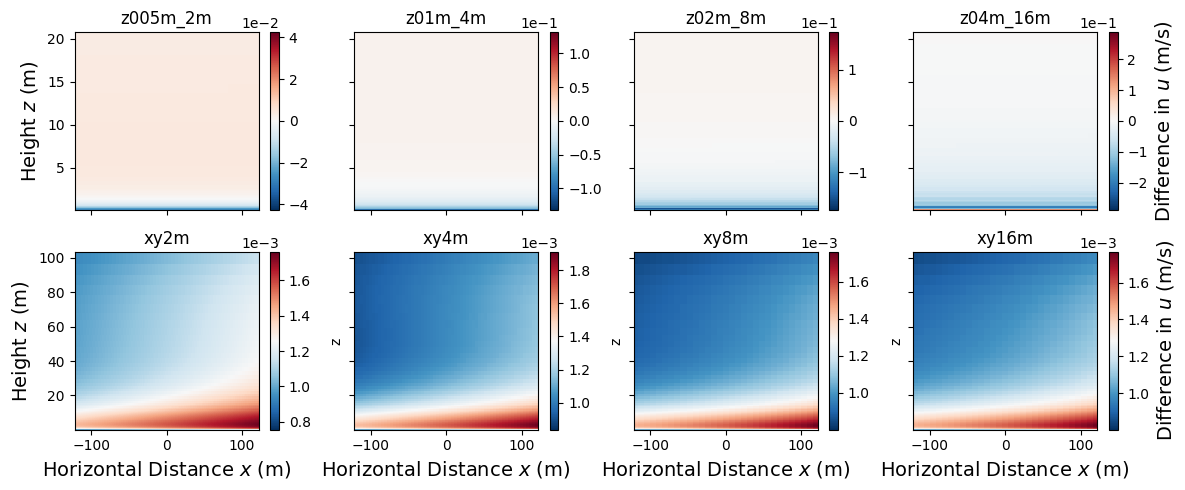

In [15]:
fig, ax = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey='row')

i, j = 0, 0
for key in plot_keys:
    if key.startswith('z'):
        diff = wind[key].ds.U - wind['z0025m_1m'].ds.U
        cb = diff.sel(y=0, x=slice(-120,120), z=slice(0.1,20.09233003)).plot(x='x', y='z', cmap='RdBu_r', ax=ax[0, i])
        # scientific notation for colorbar ticks
        cb.colorbar.set_label('')
        if i == 3:
            cb.colorbar.set_label('Difference in $u$ (m/s)', fontsize=14)
        cb.colorbar.formatter.set_powerlimits((0, 0))
        cb.colorbar.update_ticks()
        ax[0, i].set_title(key)
        ax[0, i].set_xlabel('')
        ax[0, i].set_ylabel('')
        ax[0, 0].set_ylabel('Height $z$ (m)', fontsize=14)
        i += 1
    else:
        diff = wind[key].ds.U - wind['xy1m'].ds.U
        cb = diff.sel(y=0, x=slice(-200,200), z=slice(0.1,100)).plot(x='x', y='z', cmap='RdBu_r', ax=ax[1, j])
        # scientific notation for colorbar ticks
        cb.colorbar.formatter.set_powerlimits((0, 0))
        cb.colorbar.update_ticks()
        cb.colorbar.set_label('')
        if j == 3:
            cb.colorbar.set_label('Difference in $u$ (m/s)', fontsize=14)

        ax[1, 0].set_ylabel('Height $z$ (m)', fontsize=14)
        ax[1, j].set_xlabel('Horizontal Distance $x$ (m)', fontsize=14)
        ax[1, j].set_title(key)
        j += 1
plt.tight_layout()

In [ ]:
shots = ["Driver", "3-wood", "5-wood", "Hybrid", "4 Iron", "5 Iron", "6 Iron", "7 Iron", "8 Iron", "9 Iron", "PW"]
# Define a helper function for a single run to be used in parallel processing
def simulate_single_shot(shot_type, wind, solver='rk45', rotation=0):
    # Re-initialize or pass objects safely inside the worker
    P0 = get_rotated_geometry(rotation, r=100)  # Adjust the radius as needed
    P0 += np.array([2, 2, 0])  # Add a small offset to ensure the initial position is not exactly at the origin
    traj = PGA(shot_type, wind=wind, orientation=rotation, P0=P0)

    traj.solve(solver, rtol=1e-5)

    return traj.p[-1][:2], np.max(traj.p[:, 2]), P0

In [17]:
try:
    joblib.load("grid_study_results2.joblib")
    print("Results already exist. Skipping simulation.")
except FileNotFoundError:
    # create pandas dataframe to store results for all shots and wind conditions + angles
    angles = np.arange(15, 375, 30)

    all_tasks = [
        (key, shot, angle)
        for key in filenames
        for shot in shots
        for angle in angles
    ]

    results = Parallel(n_jobs=-1)(
        delayed(simulate_single_shot)(shot, wind[key], rotation=angle)
        for key, shot, angle in all_tasks
    )

    rows = []
    for (key, shot, angle), (landingpoint, max_height, P0) in zip(all_tasks, results):
        rows.append({
            "shot_type": shot,
            "wind_key": key,
            "wind_direction": angle,
            "starting_point": P0,
            "landing_point": landingpoint,
            "x": landingpoint[0],
            "y": landingpoint[1],
            "max_height": max_height,
        })
    df = pd.DataFrame(rows)
    #joblib.dump(df, "grid_study_results_rolled_skewed.joblib")

In [42]:
ref_z = df[df['wind_key'] == 'z005m_2m']
ref_xy = df[df['wind_key'] == 'xy2m']

# find the differnce between the points for each key and the reference points
for key in sorted_keys:
    mask = df['wind_key'] == key
    ref = ref_z if key.startswith('z') else ref_xy
    df.loc[mask, 'x_diff'] = df.loc[mask, 'x'].values - ref['x'].values
    df.loc[mask, 'y_diff'] = df.loc[mask, 'y'].values - ref['y'].values
    df.loc[mask, 'mh_diff'] = df.loc[mask, 'max_height'].values - ref['max_height'].values

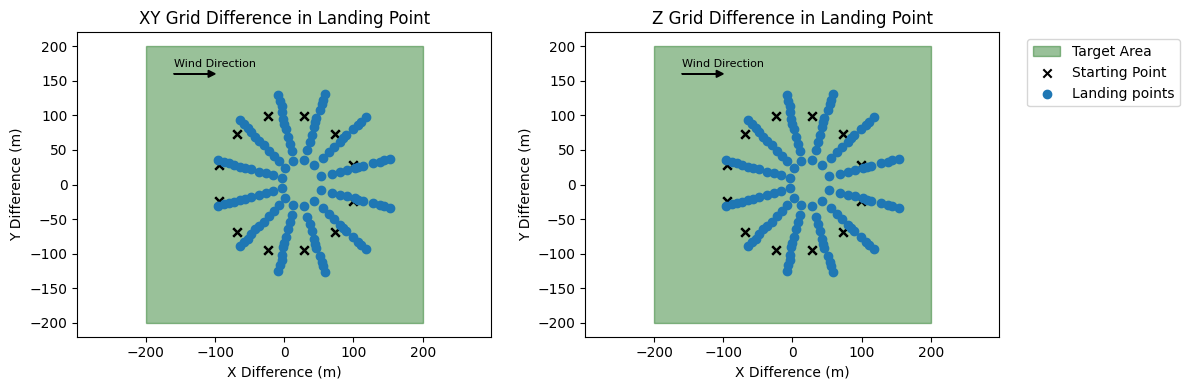

In [43]:
fig, ax = plt.subplots(1,2,figsize=(12, 4))

colors = plt.cm.bwr([0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0])

subset = df[df['shot_type'] == 'Driver']

ax[0].add_patch(plt.Rectangle((-200, -200), 400, 400, color='darkgreen', alpha=0.4, label='Target Area'))
ax[1].add_patch(plt.Rectangle((-200, -200), 400, 400, color='darkgreen', alpha=0.4, label='Target Area'))
ax[0].scatter(subset['starting_point'][:36].apply(lambda p: p[0]), subset['starting_point'][:36].apply(lambda p: p[1]), alpha=1, marker='x', label='Starting Point', color='black')
ax[1].scatter(subset['starting_point'][:36].apply(lambda p: p[0]), subset['starting_point'][:36].apply(lambda p: p[1]), alpha=1, marker='x', label='Starting Point', color='black')


subset = df[df['wind_key'] == 'z0025m_1m']

ax[0].scatter(subset['x'], subset['y'], label='Landing points')

subset = df[df['wind_key'] == 'xy1m']

ax[1].scatter(subset['x'], subset['y'], label='Landing points')

# add arrow indicating wind direction
ax[0].arrow(-160,160, 50, 0, head_width=10, head_length=10, fc='black', ec='black')
ax[0].text(-160, 170, 'Wind Direction', fontsize=8, ha='left')
ax[1].arrow(-160,160, 50, 0, head_width=10, head_length=10, fc='black', ec='black')
ax[1].text(-160, 170, 'Wind Direction', fontsize=8, ha='left')
ax[0].set_title("XY Grid Difference in Landing Point")
ax[1].set_title("Z Grid Difference in Landing Point")
ax[0].set_xlabel("X Difference (m)")
ax[0].set_ylabel("Y Difference (m)")
ax[1].set_xlabel("X Difference (m)")
ax[1].set_ylabel("Y Difference (m)")
ax[0].axis('equal')
ax[1].axis('equal')

ax[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

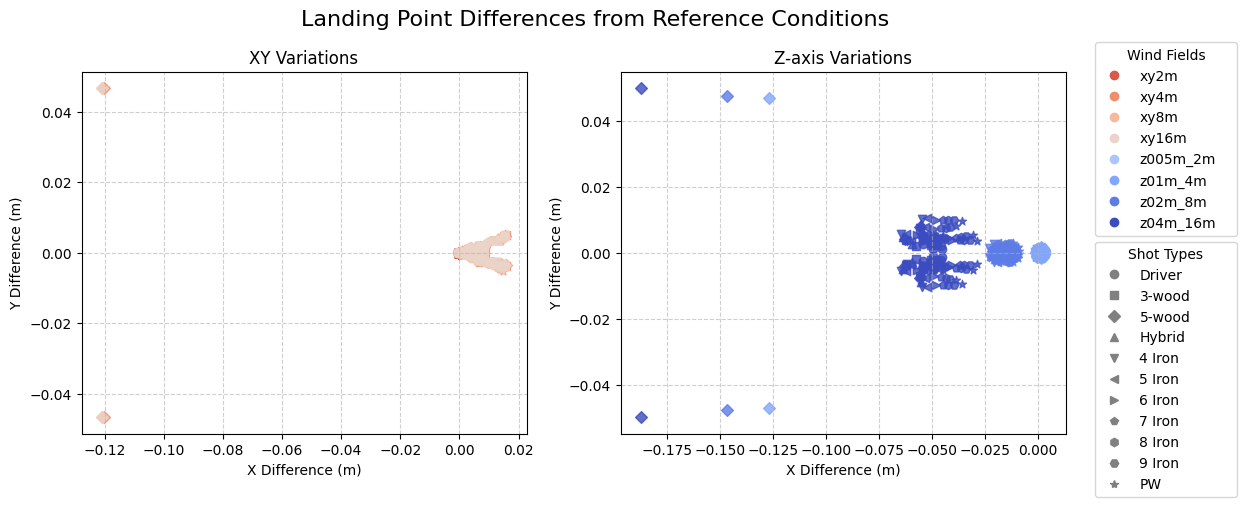

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5)) # Slightly widened to fit legends side-by-side

# Fixing the color map definition from your snippet
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(sorted_keys)))
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', 'H', '*']

# 1. Plotting Loop
for key in plot_keys:
    subset = df[df['wind_key'] == key]
    for shot in shots:
        subsubset = subset[subset['shot_type'] == shot]
        
        # Determine correct axis based on key
        target_ax = ax[1] if key.startswith('z') else ax[0]
        
        target_ax.scatter(
            subsubset['x_diff'], 
            subsubset['y_diff'], 
            alpha=0.8, 
            color=colors[sorted_keys.index(key)], 
            marker=markers[shots.index(shot)]
        )

# 2. Define Custom Legend Handles
# Key (Color) Handles
key_handles = [
    mlines.Line2D([], [], color=colors[sorted_keys.index(key)], marker='o', ls='', label=key)
    for key in plot_keys
]

# Shot (Marker) Handles - Using a neutral gray color to focus on the shape
shot_handles = [
    mlines.Line2D([], [], color='gray', marker=markers[shots.index(shot)], ls='', label=shot)
    for shot in shots
]

# 3. Apply Both Legends to the Subplots
# We will put the Keys legend first, then overlay the Shots legend next to it
# Add the Key (Color) Legend
leg1 = ax[1].legend(handles=key_handles, title="Wind Fields", bbox_to_anchor=(1.05, 1.1,0.35,0), loc='upper left', mode="expand")
# Manually add it back so it isn't overwritten
ax[1].add_artist(leg1)

# Add the Shot (Marker) Legend shifted further right (bbox_to_anchor X altered)
ax[1].legend(handles=shot_handles, title="Shot Types", bbox_to_anchor=(1.05, 0.55,0.35,0), loc='upper left', mode="expand")

# 4. Formatting Final Touches
for i in range(2):
    ax[i].grid(True, linestyle='--', alpha=0.6)
    ax[i].set_xlabel('X Difference (m)')
    ax[i].set_ylabel('Y Difference (m)')

ax[0].set_title('XY Variations')
ax[1].set_title('Z-axis Variations')

plt.suptitle('Landing Point Differences from Reference Conditions', fontsize=16)

plt.tight_layout()
plt.show()

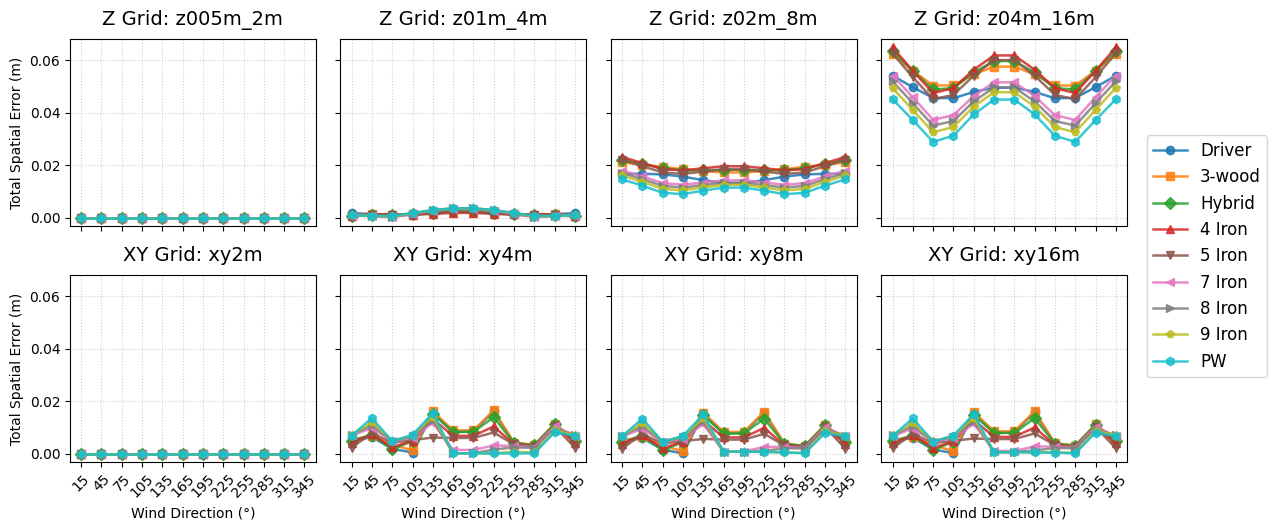

In [45]:
shot_types = df['shot_type'].unique()
shot_types = np.delete(shot_types, [2, 6])

# 1. Calculate the total spatial error magnitude from your differences
df['total_spatial_error'] = np.sqrt(df['x_diff']**2 + df['y_diff']**2)

# 2. Group your keys explicitly so we can map them to the 4x2 layout
# (Ordered from coarsest to finest for logical reading left-to-right)
xy_keys = plot_keys[0:4]  # Replace with your actual XY keys
z_keys = plot_keys[4:8]  # Replace with your actual Z keys

angles = sorted(df['wind_direction'].unique())

# 3. Define styling dictionaries for the shot types to keep them consistent
colors = plt.cm.tab10(np.linspace(0, 1, len(shot_types)))
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', 'H', '*']
shot_styles = {shot: {'color': colors[i % len(colors)], 'marker': markers[i % len(markers)]} 
               for i, shot in enumerate(shot_types)}

# 4. Initialize the 2x4 Subplot Grid
# sharex ensures wind angles match; sharey allows easy magnitude comparison across grids
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True, sharey=True)

# --- Row 1: Z Grid Progressions ---
for j, key in enumerate(z_keys):
    ax = axes[0, j]
    grid_df = df[df['wind_key'] == key]
    
    for shot in shot_types:
        shot_df = grid_df[grid_df['shot_type'] == shot].sort_values('wind_direction')
        ax.plot(
            shot_df['wind_direction'], 
            shot_df['total_spatial_error'], 
            label=shot, 
            linewidth=1.8,
            alpha=0.85,
            **shot_styles[shot]
        )
    ax.set_title(f"Z Grid: {key}", fontsize=14, pad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

# --- Row 2: XY Grid Progressions ---
for j, key in enumerate(xy_keys):
    ax = axes[1, j]
    grid_df = df[df['wind_key'] == key]
    
    for shot in shot_types:
        shot_df = grid_df[grid_df['shot_type'] == shot].sort_values('wind_direction')
        ax.plot(
            shot_df['wind_direction'], 
            shot_df['total_spatial_error'], 
            label=shot, 
            linewidth=1.8,
            alpha=0.85,
            **shot_styles[shot]
        )
    ax.set_title(f"XY Grid: {key}", fontsize=14, pad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

# 5. Formatting X and Y labels securely across outer edges
for ax in axes[1, :]:
    ax.set_xlabel("Wind Direction (°)", fontsize=10)
    ax.set_xticks(angles)
    ax.set_xticklabels(angles, rotation=45)

for ax in axes[:, 0]:
    ax.set_ylabel("Total Spatial Error (m)", fontsize=10)

# 6. Build a singular unified legend centered at the top
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(1.03, 0.7), fontsize=12)

# Adjust padding to ensure titles, labels, and legends don't overlap
plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.92])

plt.show()

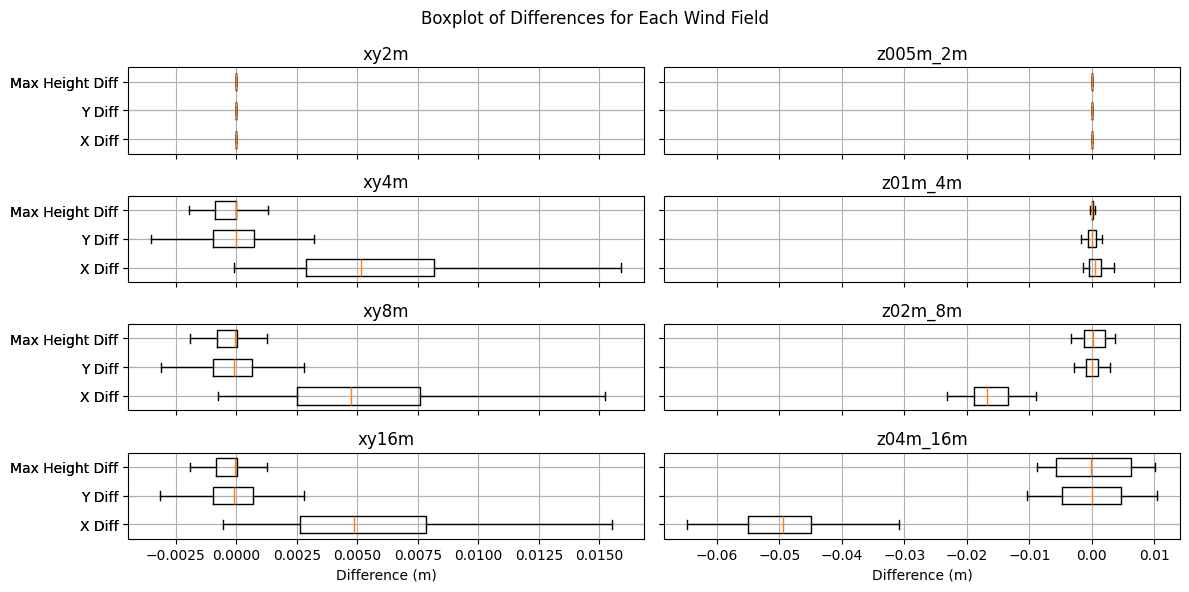

In [46]:
# boxplot of differnces for each key
fig, ax = plt.subplots(4, 2, figsize=(12, 6), sharey='row', sharex='col')
for i, key in enumerate(plot_keys):
    subset = df[df['wind_key'] == key]
    ax[i%4, i//4].boxplot([subset['x_diff'], subset['y_diff'], subset['mh_diff']], tick_labels=['X Diff', 'Y Diff', 'Max Height Diff'], showfliers=False, orientation='horizontal', widths=0.6)
    ax[i%4, i//4].grid()
    ax[i%4, i//4].set_title(key)
ax[3,0].set_xlabel('Difference (m)')
ax[3,1].set_xlabel('Difference (m)')
plt.suptitle('Boxplot of Differences for Each Wind Field')

plt.tight_layout()
plt.show()

In [47]:
# find x and y mean for every wind key in pd.DataFrame
df['abs_diff'] = np.sqrt(df['x_diff']**2 + df['y_diff']**2)

for key in plot_keys:
    key_mask = df['wind_key'] == key
    ref_point = ref_z if key.startswith('z') else ref_xy
    mean_value = np.linalg.norm(df[key_mask][['x', 'y']].values - ref_point[['x', 'y']].values, axis=1).mean()
    df.loc[key_mask, 'mean_distance'] = mean_value


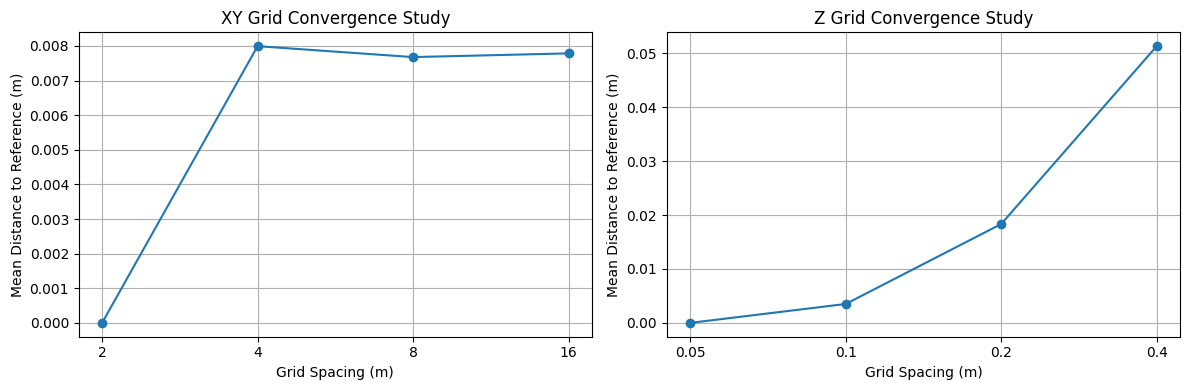

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot([df[df['wind_key'] == key]['mean_distance'].iloc[0] for key in plot_keys if key.startswith('xy')], marker='o')
ax[1].plot([df[df['wind_key'] == key]['mean_distance'].iloc[0] for key in plot_keys if key.startswith('z')], marker='o')

ax[0].grid()
ax[1].grid()
ax[0].set_xticks(range(4))
ax[1].set_xticks(range(4))
ax[0].set_xticklabels(['2', '4', '8', '16'])
ax[1].set_xticklabels(['0.05', '0.1', '0.2', '0.4'])
ax[0].set_xlabel('Grid Spacing (m)')
ax[0].set_ylabel('Mean Distance to Reference (m)')
ax[0].set_title('XY Grid Convergence Study')
ax[1].set_xlabel('Grid Spacing (m)')
ax[1].set_ylabel('Mean Distance to Reference (m)')
ax[1].set_title('Z Grid Convergence Study')
plt.tight_layout()
plt.show()